In [3]:
%pip install yfinance pandas matplotlib

  Using cached yfinance-1.7.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached beautifulsoup4-4.15.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached curl_cffi-0.16.3-cp310-abi3-macosx_11_0_arm64.whl.metadata (17 kB)
  Using cached lxml-6.1.3-cp313-cp313-macosx_10_13_universal2.whl.metadata (3.3 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached peewee-4.5.0-py3-none-any.whl.metadata (10 kB)
  Using cached protobuf-7.36.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached pytz-2026.3.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached websockets-17.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached soupsieve-2.9.2-py3-none-any.whl.metadata (4.6 kB)
  Using cached cffi-2.1.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.5 kB)
  Using cached charset_normalizer-3.5.1-cp313-cp313-macosx_10_13_universal2.whl.metadata (45 kB)
  Using cached 

[*********************100%***********************]  5 of 5 completed

Fetching data from Yahoo Finance...

--- Last 5 Days Closing Prices ---
Ticker      ASIAN.BK  CFRESH.BK  SSF.BK  TC.BK  TU.BK
Date                                                 
2026-08-31      7.30       1.91    5.05   8.25   12.6
2026-09-01      7.25       1.86    5.00   8.15   12.7
2026-09-02      7.15       1.77    5.00   8.25   12.9
2026-09-03      7.15       1.69    5.05   8.25   13.2
2026-09-04      7.10       1.71    5.05   8.25   13.1


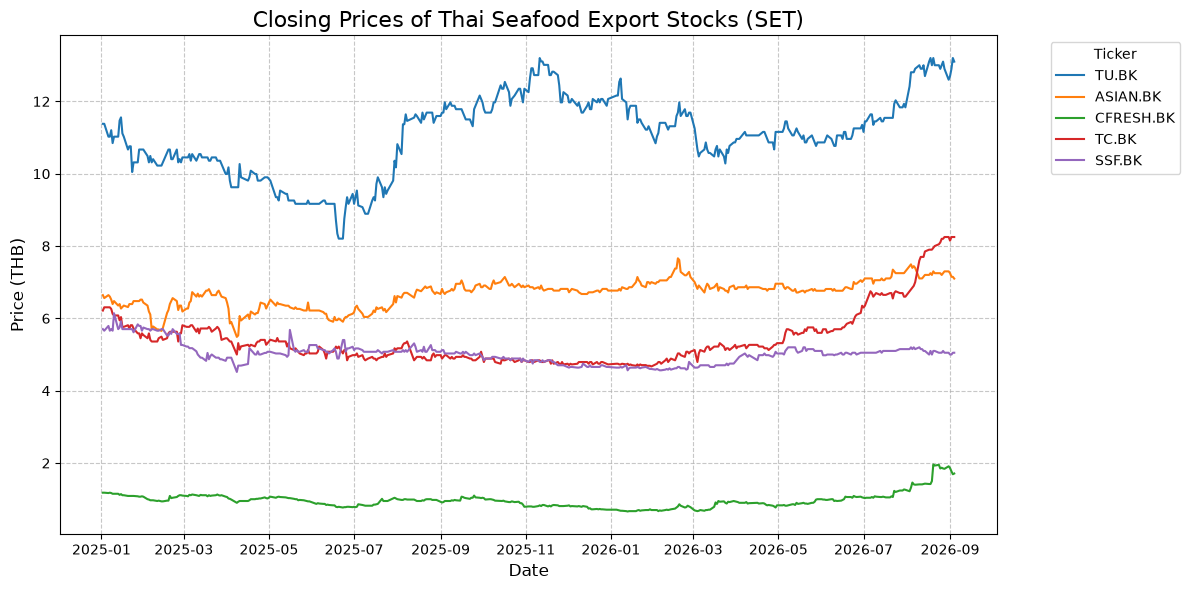

In [5]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. กำหนดรายชื่อหุ้นกลุ่มส่งออกอาหารทะเล (ต้องใส่ .BK สำหรับตลาดหุ้นไทย)
tickers = ["TU.BK", "ASIAN.BK", "CFRESH.BK", "TC.BK", "SSF.BK"]

# 2. กำหนดช่วงเวลาที่ต้องการดึงข้อมูล (รูปแบบ YYYY-MM-DD)
start_date = "2025-01-01"
end_date = "2026-09-07"

print("Fetching data from Yahoo Finance...")
# 3. ใช้ yf.download() เพื่อดึงข้อมูลทั้งหมด
data = yf.download(tickers, start=start_date, end=end_date)

# 4. กรองเอาเฉพาะ "ราคาปิด" (Close) มาใช้งาน
close_prices = data['Close']

# แสดงผลข้อมูล 5 วันทำการล่าสุด
print("\n--- Last 5 Days Closing Prices ---")
print(close_prices.tail())

# 5. พล็อตกราฟเปรียบเทียบราคาหุ้น
plt.figure(figsize=(12, 6))

# วนลูปวาดกราฟหุ้นแต่ละตัว
for ticker in tickers:
    # จัดการข้อมูลที่อาจเป็นค่าว่าง (NaN) ด้วยการเติมค่าก่อนหน้าเพื่อไม่ให้กราฟขาด
    plt.plot(close_prices.index, close_prices[ticker].ffill(), label=ticker)

# ตกแต่งกราฟ (เปลี่ยนเป็นภาษาอังกฤษทั้งหมด)
plt.title('Closing Prices of Thai Seafood Export Stocks (SET)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (THB)', fontsize=12)
plt.legend(title='Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# แสดงกราฟ
plt.show()

In [6]:
import yfinance as yf
import pandas as pd

# 1. กำหนดรายชื่อหุ้น
tickers = ["TU.BK", "ASIAN.BK", "CFRESH.BK", "TC.BK", "SSF.BK"]

# 2. ใช้ yf.download() พร้อมกำหนด period="5y" เพื่อดึงข้อมูลย้อนหลัง 5 ปีอัตโนมัติ
print("Fetching 5-year data from Yahoo Finance...")
data = yf.download(tickers, period="5y")

# 3. กรองเอาเฉพาะ "ราคาปิด" (Close)
close_prices = data['Close']

# 4. จัดการข้อมูลสูญหาย (ถ้ามี) ด้วยการ forward-fill
close_prices = close_prices.ffill()

# 5. กำหนดชื่อไฟล์ CSV ที่ต้องการเซฟ
csv_filename = "thai_seafood_stocks_5yrs.csv"

# 6. บันทึกข้อมูลลงไฟล์ CSV
close_prices.to_csv(csv_filename)

print(f"\n✅ ดึงข้อมูลสำเร็จ! เซฟไฟล์ไว้ที่: {csv_filename}")

# แสดงตัวอย่างข้อมูล 5 วันแรก
print("\n--- ตัวอย่างข้อมูลที่เซฟลง CSV ---")
print(close_prices.head())

Fetching 5-year data from Yahoo Finance...


[*********************100%***********************]  5 of 5 completed


✅ ดึงข้อมูลสำเร็จ! เซฟไฟล์ไว้ที่: thai_seafood_stocks_5yrs.csv

--- ตัวอย่างข้อมูลที่เซฟลง CSV ---
Ticker       ASIAN.BK  CFRESH.BK    SSF.BK     TC.BK      TU.BK
Date                                                           
2021-09-07  12.135022       2.42  6.270222  4.695757  15.586736
2021-09-08  12.832437       2.40  6.232900  4.818255  16.594837
2021-09-09  12.832437       2.42  6.270222  4.899921  16.749931
2021-09-10  12.762696       2.42  6.270222  4.899921  16.827477
2021-09-13  13.041662       2.44  6.232900  4.859089  16.672384


In [9]:
import yfinance as yf
import pandas as pd

# 1. กำหนดรายชื่อหุ้นกลุ่มอาหารทะเลไทย (ใส่ .BK เพื่อบอกว่าเป็นของ SET)
tickers = ["TU.BK", "ASIAN.BK", "CFRESH.BK", "TC.BK", "SSF.BK"]

# 2. กำหนดวันที่ (ล็อกช่วงเวลาให้ครอบคลุมปี 2021 ถึงปัจจุบัน)
start_date = "2021-09-01"
end_date = "2026-09-08"

print("🌐 กำลังเชื่อมต่อเพื่อดึงข้อมูลจริงจากตลาดหุ้น...")

# 3. คำสั่งดึงข้อมูลจริงจาก Yahoo Finance
data = yf.download(tickers, start=start_date, end=end_date)

# 4. เลือกเฉพาะ "ราคาปิด" (Close) 
close_prices = data['Close']

# 5. เติมเต็มข้อมูลในวันที่ตลาดปิด หรือหุ้นบางตัวอาจไม่มีการซื้อขาย (Forward-fill)
close_prices = close_prices.ffill()

# 6. ตั้งชื่อไฟล์และบันทึกออกมาเป็น CSV บนเครื่องของคุณ
csv_filename = "real_seafood_stocks_5yrs.csv"
close_prices.to_csv(csv_filename)

print(f"\n✅ ดึงข้อมูลสำเร็จ! บันทึกไฟล์ชื่อ: {csv_filename} เรียบร้อยแล้ว")

# 7. --- ส่วนสำหรับพิสูจน์ความถูกต้อง (Data Validation) ---
print("\n--- 🎯 ตรวจสอบความถูกต้องของข้อมูล ---")
try:
    # ดึงเฉพาะราคาของ ASIAN.BK ในวันที่ 2021-09-07 มาโชว์
    asian_price = close_prices.loc['2026-09-07', 'ASIAN.BK']
    print(f"ราคาปิด ASIAN.BK ณ วันที่ 2021-09-07 คือ: {asian_price:.2f} บาท")
except KeyError:
    print("ไม่พบข้อมูลวันที่ 2021-09-07 (อาจเป็นวันหยุด)")

🌐 กำลังเชื่อมต่อเพื่อดึงข้อมูลจริงจากตลาดหุ้น...


[*********************100%***********************]  5 of 5 completed


✅ ดึงข้อมูลสำเร็จ! บันทึกไฟล์ชื่อ: real_seafood_stocks_5yrs.csv เรียบร้อยแล้ว

--- 🎯 ตรวจสอบความถูกต้องของข้อมูล ---
ราคาปิด ASIAN.BK ณ วันที่ 2021-09-07 คือ: 7.20 บาท
